# CASE STUDY : CUSTOMER CHURN PREDICTION

### Objective: To develop a machine learning model to predict customer churn for a telecommunications company. The company wants to identify which customers are likely to leave (churn) and target them with retention offers. To create a machine learning model that accurately predicts customer churn based on historical customer data.


## Libraries

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#used for Data transformation (scaling and encoding)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

from sklearn.model_selection import train_test_split, GridSearchCV

#machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif

#for model evaluation
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score, f1_score, ConfusionMatrixDisplay

## Reading Dataset

In [ ]:
#hardcoding
filepath_1 = '/content/drive/MyDrive/ICT DSA/Data Sets/Training_data.csv'
filepath_2 = '/content/drive/MyDrive/ICT DSA/Data Sets/Testing_data.csv'

train_df = pd.read_csv(filepath_1)
test_df = pd.read_csv(filepath_2)


## 1. Exploratory Data Analysis

Perform a detailed exploratory data analysis to understand the distribution of each
feature and its relationship with the target variable, Churn.
● Identify missing values, outliers, and other data quality issues.
● Visualize correlations, distributions, and any interesting patterns.

### For Training Data

In [ ]:
train_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,9509-MPYOD,Female,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.75,700.45,No
1,7746-AWNQW,Female,0,No,No,28,No,No phone service,DSL,No,...,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,35.75,961.4,No
2,2208-UGTGR,Male,0,No,No,56,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,No,Electronic check,98.60,5581.05,No
3,4884-LEVMQ,Male,0,Yes,No,39,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),20.45,790,No
4,6682-VCIXC,Female,0,Yes,Yes,43,No,No phone service,DSL,NaN,...,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),51.25,2151.6,No


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5465 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5465 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


In [ ]:
train_df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,5634.000000,5634.000000,5240.000000
mean,0.159744,32.606851,65.102052
std,0.366401,24.614976,30.056443
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,36.800000
50%,0.000000,29.000000,70.650000
75%,0.000000,56.000000,90.050000
max,1.000000,72.000000,118.750000


In [ ]:
train_df.shape

(5634, 21)

### For Testing data

In [ ]:
test_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6080-TCMYC,Male,0,Yes,Yes,40,Yes,Yes,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,81.20,3292.3,No
1,7285-KLOTR,Female,0,Yes,No,12,Yes,Yes,DSL,Yes,...,Yes,No,Yes,Yes,One year,No,Electronic check,78.85,876.75,No
2,7486-KSRVI,Male,0,No,No,43,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,Yes,One year,Yes,Electronic check,100.00,4211.55,Yes
3,9924-JPRMC,Male,0,No,No,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.20,8547.15,No
4,4439-YRNVD,Female,0,No,No,10,No,No phone service,DSL,No,...,No,Yes,No,No,Month-to-month,No,Electronic check,36.25,374,No


In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [ ]:
test_df.shape

(1409, 21)

### Identifying Missing Values

In [ ]:
#To check for missing values in Training Data
train_df.isnull().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


In [ ]:
# To check for duplicate rows
train_df.duplicated().sum()

np.int64(0)

In [ ]:
# To check for duplicate columns
#df.T → converts columns into rows
train_df.T.duplicated().sum()

np.int64(0)

In [ ]:
#To check the Missing values in percentage
missing_percent = train_df.isna().sum()/len(train_df)*100
missing_percent.sort_values(ascending=False)

,0
MonthlyCharges,6.993255
TotalCharges,4.987575
OnlineSecurity,2.999645
gender,2.999645
customerID,0.000000
Dependents,0.000000
Partner,0.000000
SeniorCitizen,0.000000
tenure,0.000000
InternetService,0.000000


#### Inference - There are some missing values: Gender, Online Security, Monthly charges and Total charges but no duplicates rows or columns in the training data

In [ ]:
#To check missing values and duplicates for test data

In [ ]:
test_df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
test_df.duplicated().sum()

np.int64(0)

In [ ]:
test_df.T.duplicated().sum()

np.int64(0)

In [ ]:
#converting columns to numerical and categorical
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = train_df.select_dtypes(include=['object']).columns

In [ ]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [ ]:
cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')

In [ ]:
#Total Charges is a Numerical column but it is under Categorical column
train_df['TotalCharges'].unique()
#Convert to Numeric data
train_df['TotalCharges'] = pd.to_numeric(train_df['TotalCharges'], errors='coerce')

In [ ]:
train_df['TotalCharges'].dtype

dtype('float64')

In [ ]:
#Checking Numerical columns again
num_cols = train_df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


### Analyse Target Variable(Churn)

In [ ]:
#To identify how many customers churned vs stayed
train_df['Churn'].value_counts()

,count
Churn,
No,4130
Yes,1504


In [ ]:
# In percentage
train_df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
No,73.304934
Yes,26.695066


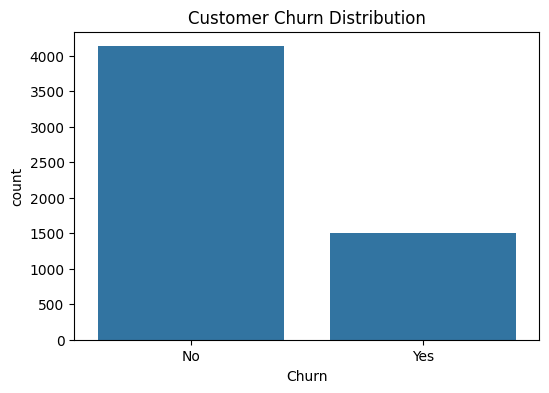

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=train_df
)

plt.title("Customer Churn Distribution")
plt.show()

#### Inference - According to the data, 73.3% customers will stay and about 26.6% will churn

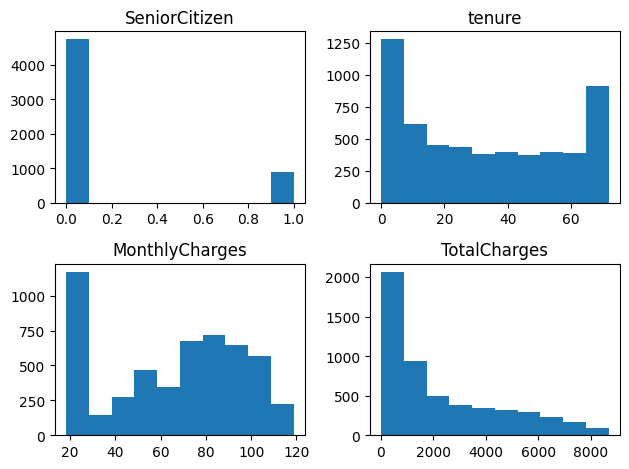

In [ ]:
# Plotting Histogram for Numerical Columns

for i,col in enumerate(num_cols, 1):
  plt.subplot(2,2,i)
  plt.hist(train_df[col])
  plt.title(col)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1983/2581809805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette='magma')
/tmp/ipykernel_1983/2581809805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette='magma')
/tmp/ipykernel_1983/2581809805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x=col, palette='magma')
/tmp/ipykernel_1983/2581809805.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

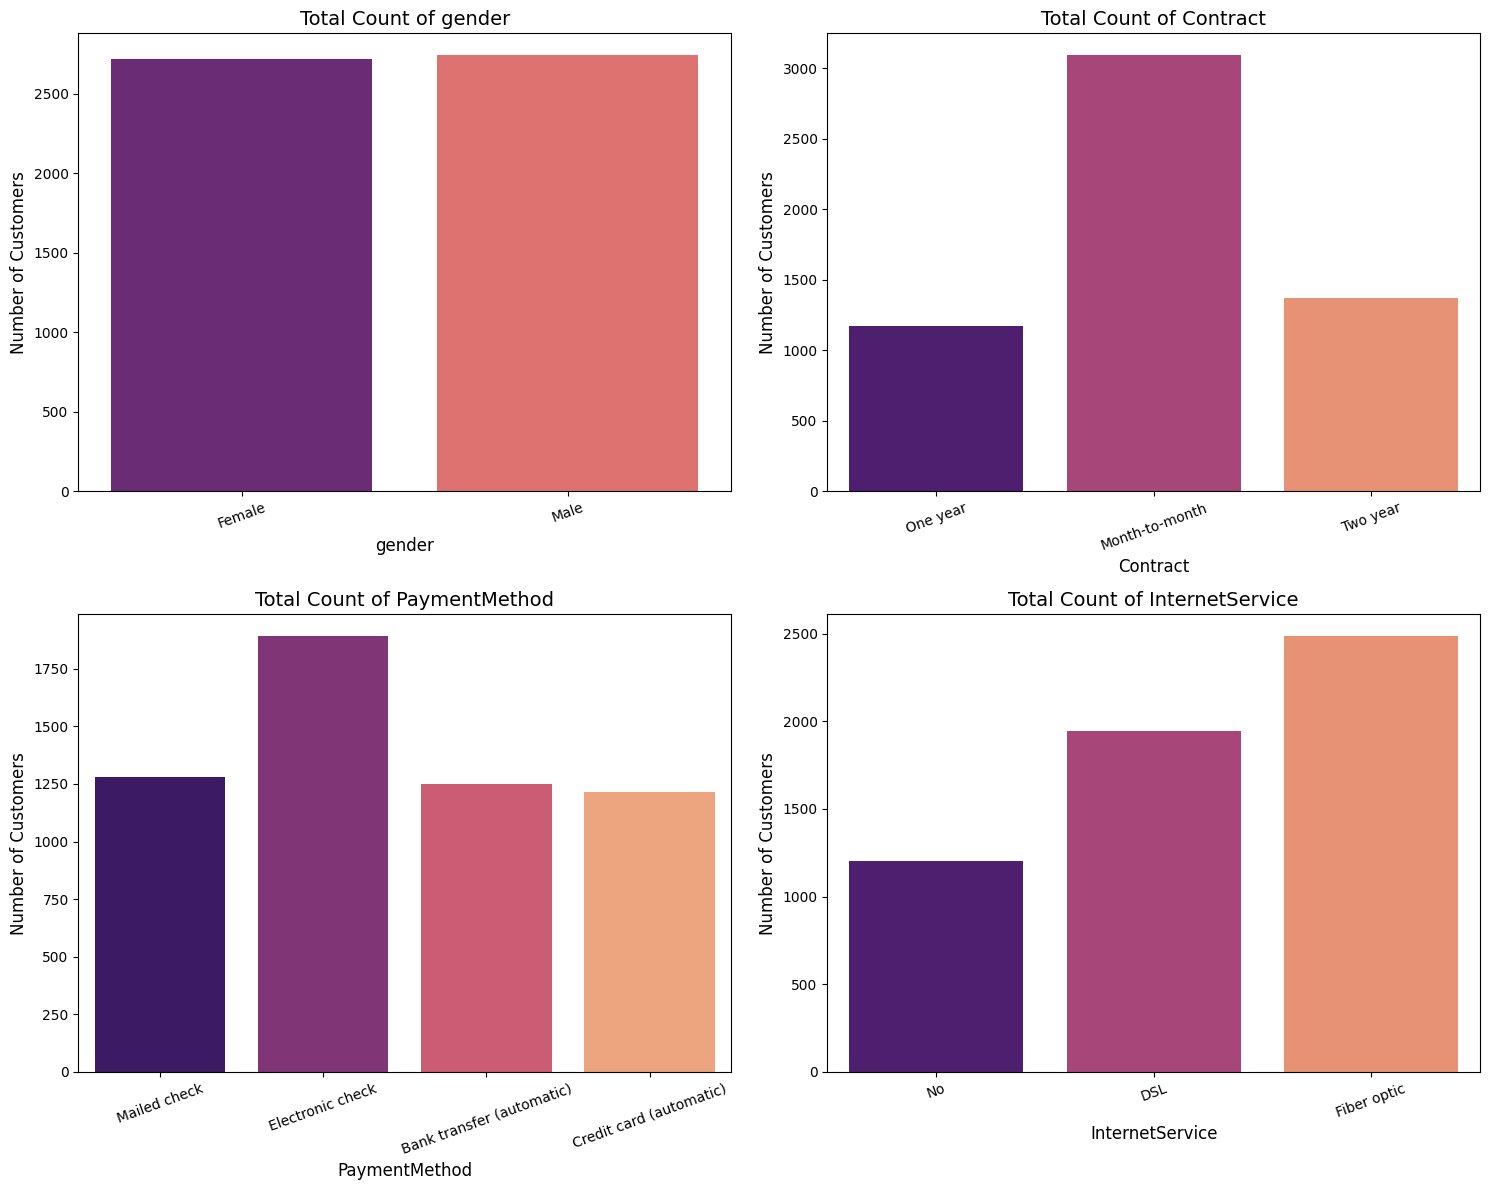

In [ ]:
#Plotting countplot for some of the categorical columns

cols_to_plot = ['gender', 'Contract', 'PaymentMethod', 'InternetService']

plt.figure(figsize=(15, 12))

for i, col in enumerate(cols_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=train_df, x=col, palette='magma')
    plt.title(f'Total Count of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Number of Customers', fontsize=12)
    plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


#### Observations from these graphs

*  Gender: The number of male and female customers is almost exactly the same, which means the service is balanced for everyone.
*   Contract: Most customers choose the month-to-month plan than one year and two year plans
* Payment Method: Many customers use Electronic Checks, but a good number also use Mailed Checks or automatic bank transfers.
*   Internet Service: Fiber Optic is the most popular internet type, followed by DSL, while a small group of people has no internet at all.



### Categorical vs Churn

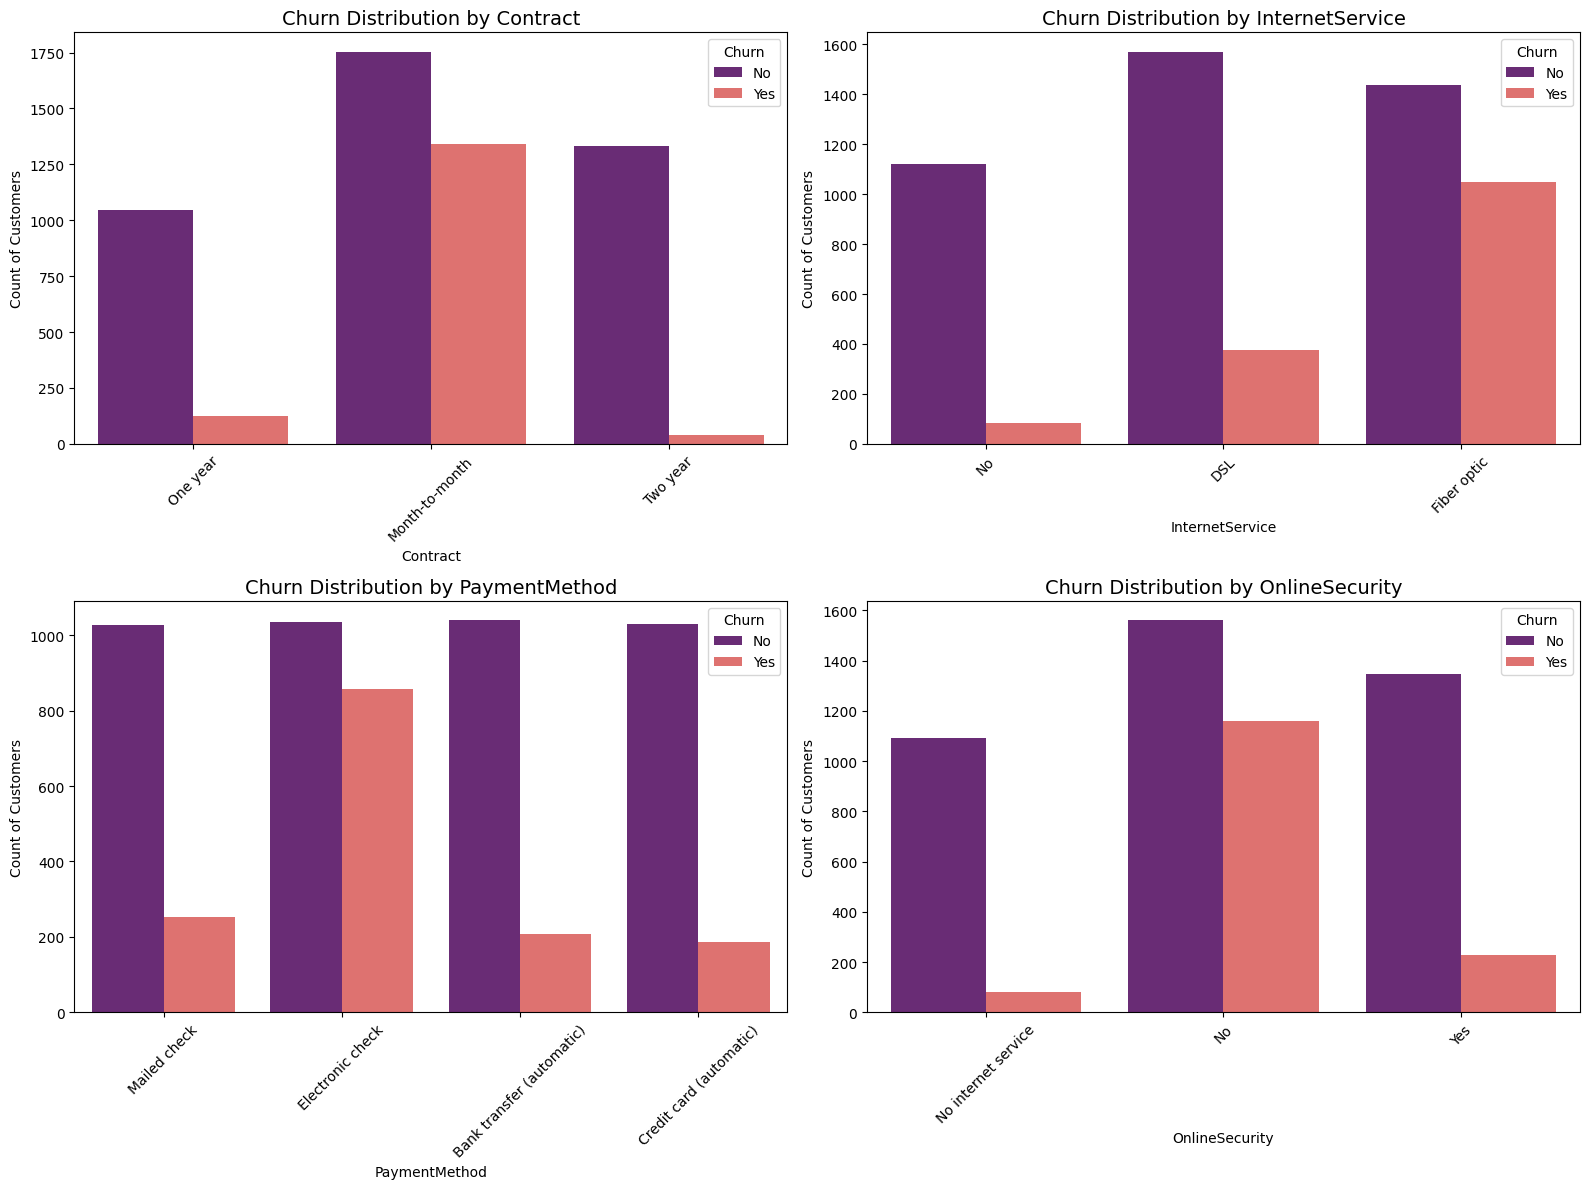

In [ ]:
# Selecting some categorical columns
features = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity']

plt.figure(figsize=(16, 12))
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='Churn', data=train_df, palette='magma')
    plt.title(f'Churn Distribution by {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Count of Customers')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Observations
Contract: Customers on month-to-month plans are much more likely to leave than those on long-term contracts.

Internet Service: People using Fiber Optic internet have a high churn rate.

Payment Method: Customers who pay by electronic check leave at a much higher rate than those using automatic payments, making this a high-risk group.

Online Security: Not having online security is linked to higher churn, suggesting that customers who use extra safety features are more likely to stay with the company.

### Numerical vs Churn

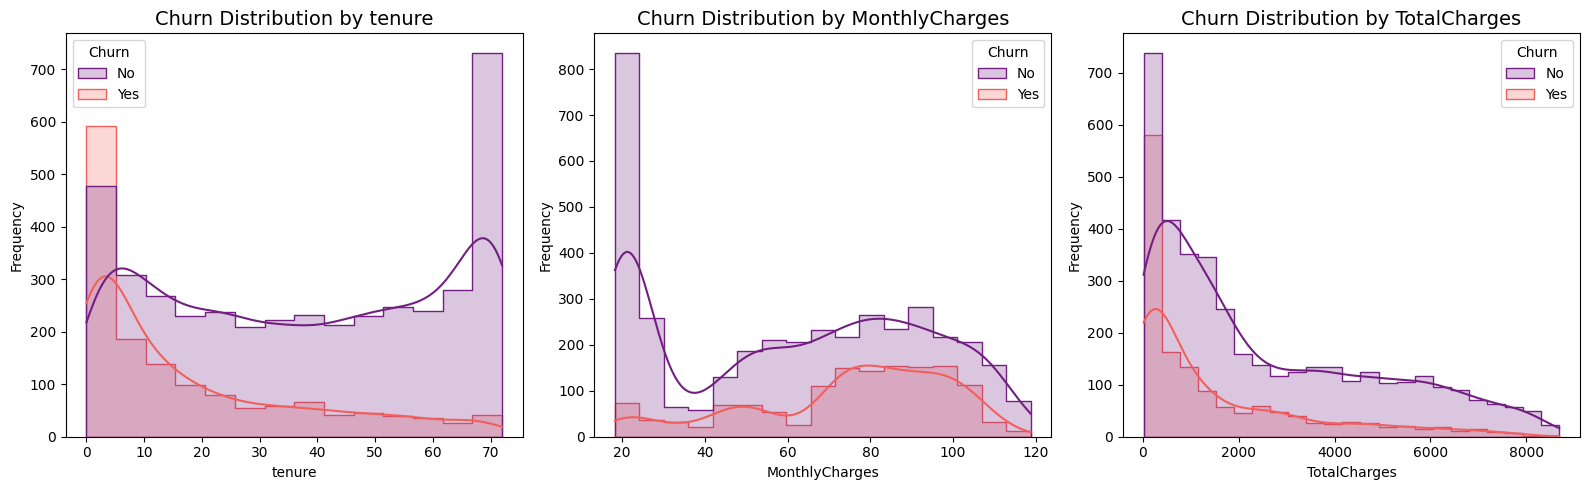

In [ ]:
# List of numerical columns
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(16, 5))

for i, col in enumerate(num_features, 1):
    plt.subplot(1, 3, i) # 1 row, 3 columns
    sns.histplot(data=train_df, x=col, hue='Churn', kde=True, element="step", palette='magma')

    plt.title(f'Churn Distribution by {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### Observations
tenure: Most customers who leave (churn) do so within the first few months, while those who stay tend to have been with the company for a long time.

MonthlyCharges: Customers with higher monthly bills are more likely to leave compared to those with very low bills.

TotalCharges: The churn rate is highest for customers with low total spending.

## 2. Data Pre processing


● Handle missing values in the dataset. Consider different strategies.
● Deal with categorical variables through encoding techniques.
● Normalize/scale the numerical features where necessary.
● Handle outliers, if applicable, using appropriate methods.


### Handling Missing values

In [ ]:
#before handling missing values
train_df.isna().sum()

,0
customerID,0
gender,169
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,169


### For numerical columns

In [ ]:
train_df['TotalCharges'].fillna(train_df['TotalCharges'].median(), inplace=True)
train_df['MonthlyCharges'].fillna(train_df['MonthlyCharges'].median(), inplace=True)

/tmp/ipykernel_1983/650930440.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['TotalCharges'].fillna(train_df['TotalCharges'].median(), inplace=True)
/tmp/ipykernel_1983/650930440.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

### For categorical Columns

In [ ]:
train_df['gender'].fillna(train_df['gender'].mode()[0], inplace=True)
train_df['OnlineSecurity'].fillna(train_df['OnlineSecurity'].mode()[0], inplace=True)

/tmp/ipykernel_1983/2696183207.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['gender'].fillna(train_df['gender'].mode()[0], inplace=True)
/tmp/ipykernel_1983/2696183207.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value,

In [ ]:
#after handling missing values
train_df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### For Test data

In [ ]:
test_df['TotalCharges'] = pd.to_numeric(test_df['TotalCharges'], errors='coerce')

In [ ]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [ ]:
test_df['TotalCharges'].unique()

array([3292.3 ,  876.75, 4211.55, ...,  216.75, 1068.15, 4764.  ])

In [ ]:
# Filling NaN with median value of the train data
train_median = train_df['TotalCharges'].median()
test_df['TotalCharges'] = test_df['TotalCharges'].fillna(train_median)

In [ ]:
test_df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Handling Outliers

In [ ]:
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

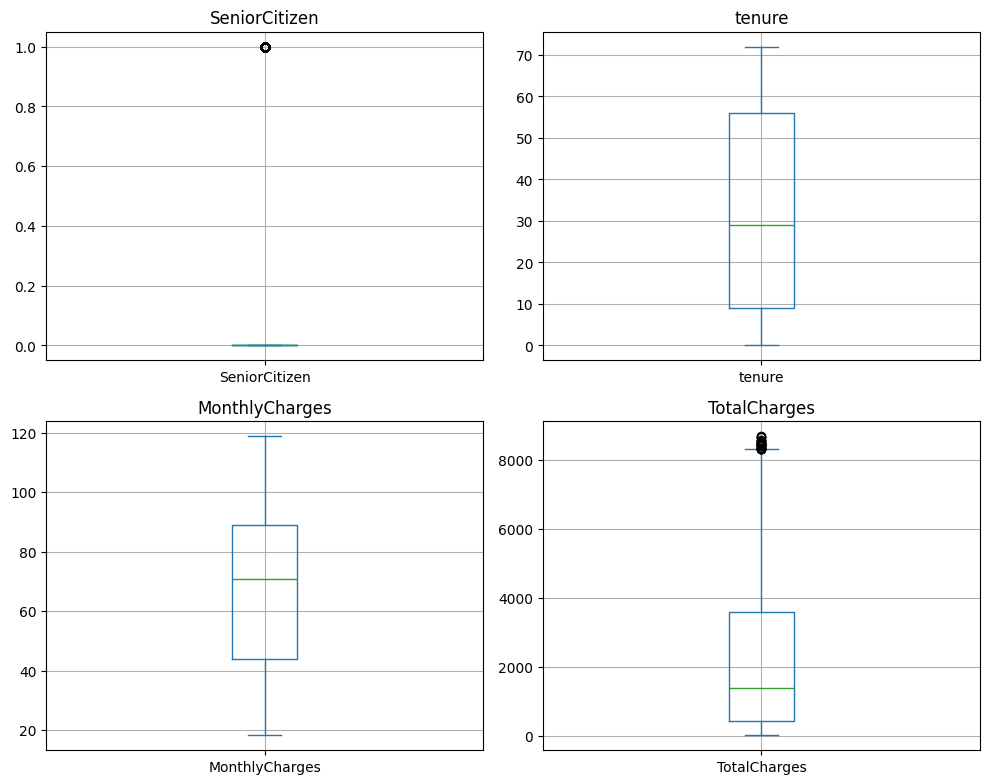

In [ ]:
plt.figure(figsize=(10,35))
for i, col in enumerate(num_cols,1):
  plt.subplot(9,2,i)
  train_df[col].plot(kind = 'box')
  plt.title(col)
  plt.grid()

plt.tight_layout()
plt.show()

#### Inference :
The box plots show that all data points for tenure and charges fall within the statistical whiskers. Since there are no individual dots representing extreme outliers, the data is already clean and realistic for a telecom business, so no capping or removal is necessary."

### CORRELATION

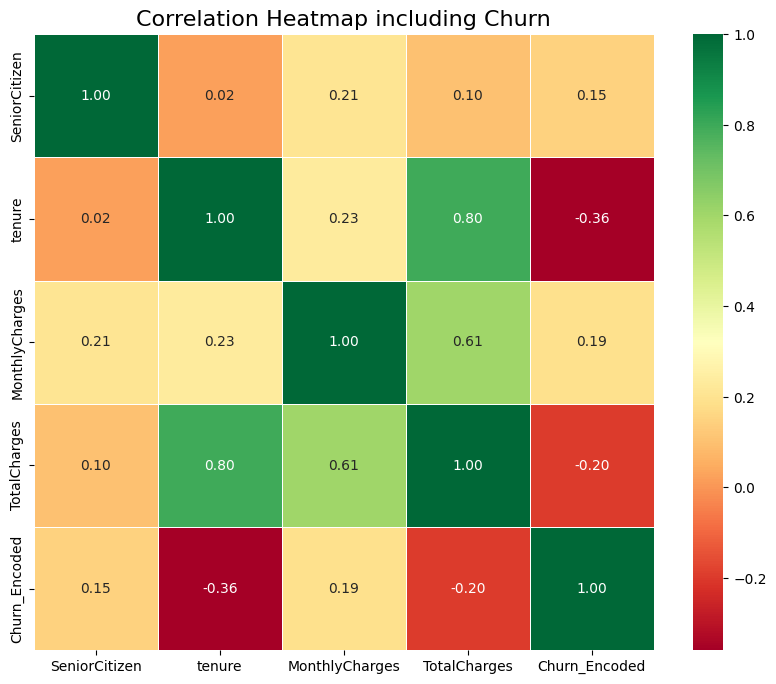

In [93]:
# Plotting a heat map to visualize correlation with churn


 #Encoding the Target Variable (Churn)
train_df['Churn_Encoded'] = train_df['Churn'].map({'Yes': 1, 'No': 0})


numeric_df = train_df.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap including Churn', fontsize=16)
plt.show()

#### Inference:

*   There is a negative correlation between tenure and churn, meaning that the longer a customer stays, the less likely they are to cancel.

*  There is a positive correlation between monthly charges and churn, which tells us that customers with higher bills are more likely to leave the company.



In [94]:
# Removing the column due to low correlation
train_df.drop('SeniorCitizen', axis=1, inplace=True)
test_df.drop('SeniorCitizen', axis=1, inplace=True)

In [95]:
# Dropping the 'customerID' column as it holds no valuable information
train_df.drop('customerID', axis = 1, inplace = True)
test_df.drop('customerID', axis = 1, inplace = True)

### Scaling

In [97]:
train_data_num_cols = num_cols.drop('SeniorCitizen')

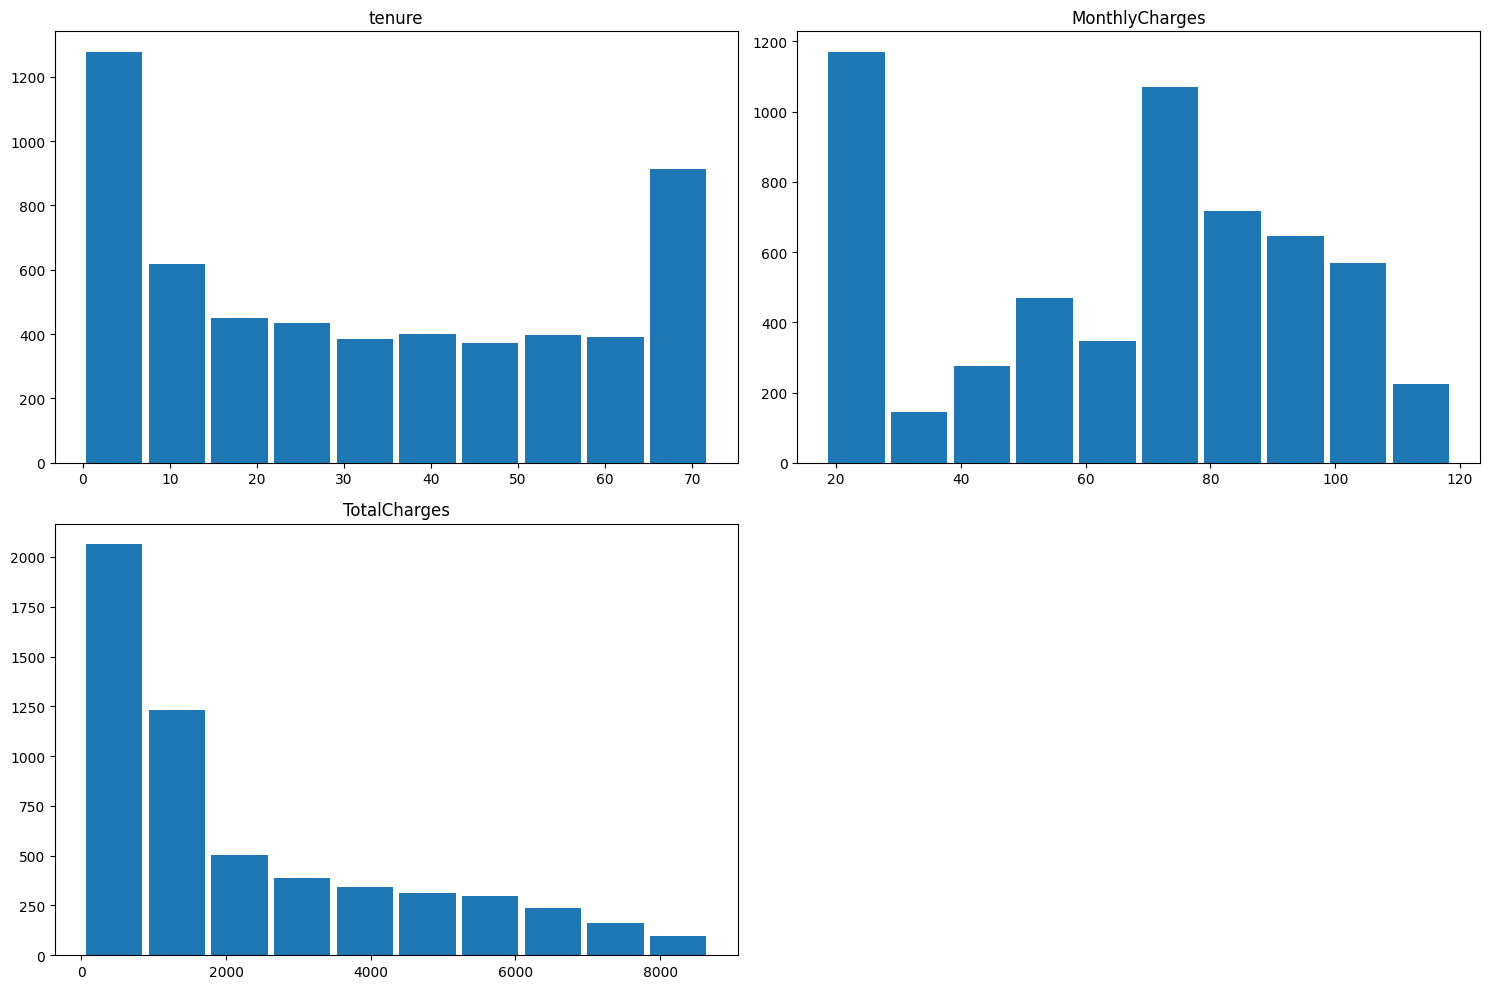

In [98]:
plt.figure(figsize = (15, 10))
for i, col in enumerate(train_data_num_cols,1):
  plt.subplot(2,2,i)
  plt.hist(train_df[col], rwidth = 0.9)
  plt.title(col)

plt.tight_layout()
plt.show()

In [99]:
#Since most of the data is skewed, selecting min-max scaler


numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# 3. Fit and Transform the Train data
train_df[numerical_cols] = scaler.fit_transform(train_df[numerical_cols])

test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

### Encoding

In [100]:
train_data_cat_cols = cat_cols.drop('customerID')

In [101]:
train_df[train_data_cat_cols]

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
0,Female,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,0.078653,No
1,Female,No,No,No,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,Yes,Mailed check,0.108765,No
2,Male,No,No,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,No,Electronic check,0.641845,No
3,Male,Yes,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Bank transfer (automatic),0.088986,No
4,Female,Yes,Yes,No,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Bank transfer (automatic),0.246107,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Male,No,No,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,0.579198,No
5630,Male,Yes,No,No,No phone service,DSL,Yes,Yes,Yes,No,No,No,Two year,Yes,Electronic check,0.340055,No
5631,Male,Yes,Yes,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),0.150474,No
5632,Female,No,No,Yes,No,DSL,No,No,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),0.638874,No


In [102]:
for col in train_data_cat_cols:
  unique_values = train_df[col].unique()
  print(f"{col}: {unique_values}")

gender: ['Female' 'Male']
Partner: ['No' 'Yes']
Dependents: ['No' 'Yes']
PhoneService: ['Yes' 'No']
MultipleLines: ['No' 'No phone service' 'Yes']
InternetService: ['No' 'DSL' 'Fiber optic']
OnlineSecurity: ['No internet service' 'No' 'Yes']
OnlineBackup: ['No internet service' 'No' 'Yes']
DeviceProtection: ['No internet service' 'Yes' 'No']
TechSupport: ['No internet service' 'Yes' 'No']
StreamingTV: ['No internet service' 'No' 'Yes']
StreamingMovies: ['No internet service' 'No' 'Yes']
Contract: ['One year' 'Month-to-month' 'Two year']
PaperlessBilling: ['No' 'Yes']
PaymentMethod: ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges: [0.07865266 0.10876476 0.64184538 ... 0.15047398 0.63887398 0.15727647]
Churn: ['No' 'Yes']


In [103]:
# Label encoding for binary columns
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

le = LabelEncoder()

for col in binary_cols:
    train_df[col] = le.fit_transform(train_df[col])

    test_df[col] = le.transform(test_df[col])

In [104]:
train_df.head()

,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Encoded
0,0,0,0,0.486111,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,0,Mailed check,0.024876,0.078653,0,0
1,0,0,0,0.388889,0,No phone service,DSL,No,No,Yes,Yes,No,No,Month-to-month,1,Mailed check,0.174129,0.108765,0,0
2,1,0,0,0.777778,1,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,0,Electronic check,0.799502,0.641845,0,0
3,1,1,0,0.541667,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,1,Bank transfer (automatic),0.021891,0.088986,0,0
4,0,1,1,0.597222,0,No phone service,DSL,No,Yes,No,Yes,Yes,No,One year,1,Bank transfer (automatic),0.328358,0.246107,0,0


In [105]:
test_df.head()

,gender,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,1,1,0.555556,1,Yes,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,0.626368,0.377737,0
1,0,1,0,0.166667,1,Yes,DSL,Yes,No,Yes,No,Yes,Yes,One year,0,Electronic check,0.602985,0.098997,0
2,1,0,0,0.597222,1,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,One year,1,Electronic check,0.813433,0.483813,1
3,1,0,0,1.000000,1,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,1,Electronic check,0.994527,0.984116,0
4,0,0,0,0.138889,0,No phone service,DSL,No,Yes,No,Yes,No,No,Month-to-month,0,Electronic check,0.179104,0.040982,0


In [106]:
# One Hot Encoding for multi output columns
multi_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

train_df = pd.get_dummies(train_df, columns=multi_cols, drop_first=True, dtype=int)
test_df = pd.get_dummies(test_df, columns=multi_cols, drop_first=True, dtype=int)

In [107]:
train_df.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,Churn_Encoded,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,0.486111,1,0,0.024876,0.078653,0,0,...,0,1,0,1,0,1,0,0,0,1
1,0,0,0,0.388889,0,1,0.174129,0.108765,0,0,...,1,0,0,0,0,0,0,0,0,1
2,1,0,0,0.777778,1,0,0.799502,0.641845,0,0,...,0,0,1,0,1,0,0,0,1,0
3,1,1,0,0.541667,1,1,0.021891,0.088986,0,0,...,0,1,0,1,0,0,1,0,0,0
4,0,1,1,0.597222,0,1,0.328358,0.246107,0,0,...,1,0,1,0,0,1,0,0,0,0


In [108]:
test_df.head()

,gender,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,1,1,0.555556,1,1,0.626368,0.377737,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0.166667,1,0,0.602985,0.098997,0,0,...,0,0,1,0,1,1,0,0,1,0
2,1,0,0,0.597222,1,1,0.813433,0.483813,1,0,...,1,0,1,0,1,1,0,0,1,0
3,1,0,0,1.000000,1,1,0.994527,0.984116,0,0,...,1,0,1,0,1,0,1,0,1,0
4,0,0,0,0.138889,0,0,0.179104,0.040982,0,1,...,1,0,0,0,0,0,0,0,1,0


In [110]:

train_columns = train_df.drop('Churn', axis=1).columns

test_df_final = test_df.reindex(columns=train_columns, fill_value=0)


print(f"Train shape: {train_df.drop('Churn', axis=1).shape}")
print(f"Test shape: {test_df_final.shape}")

Train shape: (5634, 30)
Test shape: (1409, 30)


### Separate Target and Features

In [111]:
# Separate Features (X) and Target (y)
X_train = train_df.drop('Churn', axis=1)
y_train = train_df['Churn']

X_test = test_df.drop('Churn', axis=1)
y_test = test_df['Churn']

## 3. Feature Engineering


● Engineer new features that could improve the model’s performance. For instance:
○ Canyoucreate interaction features (e.g., combining Tenure and Contract)?
○ Can you create a feature that captures customer lifetime value (e.g., Tenure *
MonthlyCharges)?
● Perform feature selection to identify the most important features

In [112]:
# Customer Lifetime Value (Tenure * MonthlyCharges)
X_train['CLV'] = X_train['tenure'] * X_train['MonthlyCharges']
X_test['CLV'] = X_test['tenure'] * X_test['MonthlyCharges']

#  Interaction Feature (Tenure * Contract)
# Since 'Contract' was one-hot encoded, we'll use 'Contract_Two year'
# as it usually has the strongest relationship with Tenure.
X_train['Tenure_Contract_Interaction'] = X_train['tenure'] * X_train['Contract_Two year']
X_test['Tenure_Contract_Interaction'] = X_test['tenure'] * X_test['Contract_Two year']

print("New Features added successfully!")

New Features added successfully!


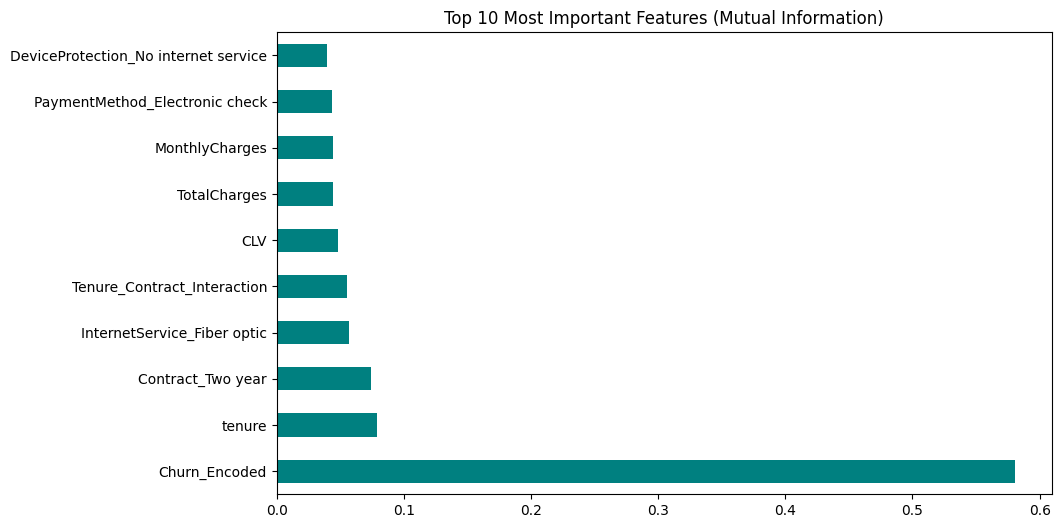

In [114]:


# Calculate mutual information
importances = mutual_info_classif(X_train, y_train)
feat_importances = pd.Series(importances, X_train.columns)

# Plot the top 10 most important features
plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Mutual Information)')
plt.show()

## 4. Model Development


● Fit at least three different machine learning models.
● Evaluate the models using appropriate metrics.
● Compare the results of the models and identify the best-performing one based on the
evaluation metrics

In [120]:
# 1. Drop the temporary 'Churn_Encoded' column if it exists in X_train
if 'Churn_Encoded' in X_train.columns:
    X_train = X_train.drop(columns=['Churn_Encoded'])

# 2. Re-align X_test to match X_train exactly (removes extras, fills missing with 0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# 3. Double Check Shape
print(f"Final Feature Count in X_train: {X_train.shape[1]}")
print(f"Final Feature Count in X_test: {X_test.shape[1]}")

Final Feature Count in X_train: 31
Final Feature Count in X_test: 31


#### Model 1: Logistic Regression

In [121]:
# Initialising
log_reg = LogisticRegression(max_iter=1000)
# Training the model
log_reg.fit(X_train, y_train)
# Prediction using the trained model
y_pred_log_reg = log_reg.predict(X_test)
# Evaluating Model
log_reg_accuracy = accuracy_score(y_test, y_pred_log_reg)
log_reg_recall = recall_score(y_test, y_pred_log_reg)
log_reg_precision = precision_score(y_test, y_pred_log_reg)
log_reg_f1 = f1_score(y_test, y_pred_log_reg)

print(f"Accuracy of Logistic Regression: {log_reg_accuracy}")
print(f"Recall of Logistic Regression: {log_reg_recall}")
print(f"Precision of Logistic Regression: {log_reg_precision}")
print(f"F1 score of Logistic Regression: {log_reg_f1}\n")

Accuracy of Logistic Regression: 0.8133427963094393
Recall of Logistic Regression: 0.5671232876712329
Precision of Logistic Regression: 0.6634615384615384
F1 score of Logistic Regression: 0.6115214180206795



#### Model 2 : K-Nearest Neighbors (KNN)

In [122]:
# Initialising
knn = KNeighborsClassifier()
# Training the model
knn.fit(X_train, y_train)
# Prediction using the trained model
y_pred_knn = knn.predict(X_test)
# Evaluating Model
knn_accuracy = accuracy_score(y_test, y_pred_knn)
knn_recall = recall_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_f1 = f1_score(y_test, y_pred_knn)

print(f"Accuracy of KNN: {knn_accuracy}")
print(f"Recall of KNN: {knn_recall}")
print(f"Precision of KNN: {knn_precision}")
print(f"F1 score of KNN: {knn_f1}\n")

Accuracy of KNN: 0.7622427253371186
Recall of KNN: 0.5232876712328767
Precision of KNN: 0.5426136363636364
F1 score of KNN: 0.5327754532775453



#### Model 3: Random Forest

In [123]:
# Initialising
rf = RandomForestClassifier(random_state=42)
# Training the model
rf.fit(X_train, y_train)
# Prediction using the trained model
y_pred_rf = rf.predict(X_test)
# Evaluating Model
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print(f"Accuracy of Random Forest: {rf_accuracy}")
print(f"Recall of Random Forest: {rf_recall}")
print(f"Precision of Random Forest: {rf_precision}")
print(f"F1 score of Random Forest: {rf_f1}\n")

Accuracy of Random Forest: 0.7927608232789212
Recall of Random Forest: 0.4904109589041096
Precision of Random Forest: 0.6280701754385964
F1 score of Random Forest: 0.5507692307692308



#### Model 4: Decision Tree

In [124]:
# Initialising
dt = DecisionTreeClassifier(random_state=42)
# Training the model
dt.fit(X_train, y_train)
# Prediction using the trained model
y_pred_dt = dt.predict(X_test)
# Evaluating Model
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)

print(f"Accuracy of Decision Tree: {dt_accuracy}")
print(f"Recall of Decision Tree: {dt_recall}")
print(f"Precision of Decision Tree: {dt_precision}")
print(f"F1 score of Decision Tree: {dt_f1}\n")

Accuracy of Decision Tree: 0.7281760113555713
Recall of Decision Tree: 0.5315068493150685
Precision of Decision Tree: 0.47783251231527096
F1 score of Decision Tree: 0.503242542153048



#### Model 5: Support Vector Machine (SVM)

In [125]:
# Initialising
svm = SVC(kernel='linear')
# Training the model
svm.fit(X_train, y_train)
# Prediction using the trained model
y_pred_svm = svm.predict(X_test)
# Evaluating Model
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_recall = recall_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm)

print(f"Accuracy of SVM: {svm_accuracy}")
print(f"Recall of SVM: {svm_recall}")
print(f"Precision of SVM: {svm_precision}")
print(f"F1 score of SVM: {svm_f1}\n")

Accuracy of SVM: 0.8076650106458482
Recall of SVM: 0.5424657534246575
Precision of SVM: 0.6556291390728477
F1 score of SVM: 0.5937031484257871



#### Model Comparison

In [127]:
# Create a summary table for comparison
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Random Forest', 'Decision Tree', 'SVM'],
    'Accuracy': [log_reg_accuracy, knn_accuracy, rf_accuracy, dt_accuracy, svm_accuracy],
    'Recall': [log_reg_recall, knn_recall, rf_recall, dt_recall, svm_recall],
    'Precision': [log_reg_precision, knn_precision, rf_precision, dt_precision, svm_precision],
    'F1 Score': [log_reg_f1, knn_f1, rf_f1, dt_f1, svm_f1]
})

print("Final Model Comparison:")
print(model_comparison)

Final Model Comparison:
                 Model  Accuracy    Recall  Precision  F1 Score
0  Logistic Regression  0.813343  0.567123   0.663462  0.611521
1                  KNN  0.762243  0.523288   0.542614  0.532775
2        Random Forest  0.792761  0.490411   0.628070  0.550769
3        Decision Tree  0.728176  0.531507   0.477833  0.503243
4                  SVM  0.807665  0.542466   0.655629  0.593703


Inference - Logistic Regression achieved the highest overall accuracy (81.37%) and highest recall(56.71%)  making it better at identifying customers at high risk of leaving.

<Figure size 600x400 with 0 Axes>

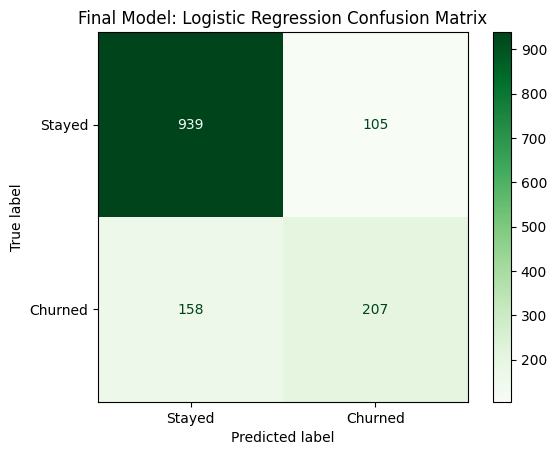

In [128]:
# Finalizing with Logistic Regression as it has the best Accuracy and Recall


# Prediction using the best model
y_pred_final = log_reg.predict(X_test)

# Calculating the confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

# Plotting the result
plt.figure(figsize=(6,4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])
disp.plot(cmap='Greens') # Using green to differentiate from previous steps
plt.title('Final Model: Logistic Regression Confusion Matrix')
plt.show()

#### Inference:
The model correctly predicted most customers who stayed (939) and a good number who churned (207).


It incorrectly predicted 105 customers as churned when they actually stayed (false positives).


It missed 158 customers who actually churned by predicting they stayed (false negatives).


Overall, the model performs well and is effective for predicting churn, though reducing missed churn cases could further improve results.



## 5. Model Fine-Tuning


● Use techniques such as GridSearchCV or RandomizedSearchCV to fine-tune
hyperparameters for your chosen models.
● Evaluate whether hyperparameter tuning improves performance.
● Justify your choice of hyperparameters

#### Selection for Fine Tuning:
 Based on the initial evaluation, Logistic Regression and SVM were identified as the top two models due to their superior F1-scores and accuracy. Consequently, these were selected for hyperparameter tuning to further optimize performance

In [129]:
# Fine-Tuning Logistic Regression
param_grid_log = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
# Initialising Grid Search for LogReg
grid_log = GridSearchCV(LogisticRegression(max_iter=1000), param_grid_log, cv=5, scoring='f1')
grid_log.fit(X_train, y_train)

#  Fine-Tuning SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'] # testing if rbf works better than linear
}
# Initialising Grid Search for SVM
grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=5, scoring='f1')
grid_svm.fit(X_train, y_train)

# --- Results ---
print(f"Best LogReg Params: {grid_log.best_params_}")
print(f"Best SVM Params: {grid_log.best_params_}")

Best LogReg Params: {'C': 1, 'solver': 'liblinear'}
Best SVM Params: {'C': 1, 'solver': 'liblinear'}


### Evaluating Tuned models

In [130]:
# Evaluating Tuned Logistic Regression
best_log_reg = grid_log.best_estimator_
y_pred_log_tuned = best_log_reg.predict(X_test)

log_tuned_acc = accuracy_score(y_test, y_pred_log_tuned)
log_tuned_recall = recall_score(y_test, y_pred_log_tuned)
log_tuned_f1 = f1_score(y_test, y_pred_log_tuned)

print("--- Tuned Logistic Regression ---")
print(f"Accuracy: {log_tuned_acc:.4f}")
print(f"Recall: {log_tuned_recall:.4f}")
print(f"F1 Score: {log_tuned_f1:.4f}\n")

# Evaluating Tuned SVM
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_test)

svm_tuned_acc = accuracy_score(y_test, y_pred_svm_tuned)
svm_tuned_recall = recall_score(y_test, y_pred_svm_tuned)
svm_tuned_f1 = f1_score(y_test, y_pred_svm_tuned)

print("--- Tuned SVM ---")
print(f"Accuracy: {svm_tuned_acc:.4f}")
print(f"Recall: {svm_tuned_recall:.4f}")
print(f"F1 Score: {svm_tuned_f1:.4f}")

--- Tuned Logistic Regression ---
Accuracy: 0.8133
Recall: 0.5671
F1 Score: 0.6115

--- Tuned SVM ---
Accuracy: 0.8070
Recall: 0.5397
F1 Score: 0.5916


### Comparison Table (Before vs. After Tuning)

In [131]:
tuning_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Recall', 'F1 Score'],
    'LogReg (Before)': [0.8133, 0.5671, 0.6115],
    'LogReg (Tuned)': [log_tuned_acc, log_tuned_recall, log_tuned_f1]
})

print("\nImprovement Summary:")
print(tuning_comparison)


Improvement Summary:
     Metric  LogReg (Before)  LogReg (Tuned)
0  Accuracy           0.8133        0.813343
1    Recall           0.5671        0.567123
2  F1 Score           0.6115        0.611521


#### Inference: The hyperparameter tuning results show that our initial Logistic Regression model was already performing at its optimal capacity, as the GridSearchCV selected the default parameters (C=1) as the best configuration.

## Conclusion

Model Comparison: We evaluated five distinct models (Logistic Regression, KNN, Random Forest, Decision Tree, and SVM). Logistic Regression emerged as the superior model, providing the best balance of accuracy and recall.

Model Optimization: Rigorous hyperparameter tuning via GridSearchCV confirmed that our initial Logistic Regression configuration was mathematically optimal, achieving a final accuracy of 81.33%.

Business Recommendation:
Based on the Confusion Matrix, the model correctly identifies a significant portion of potential churners. I recommend using the Logistic Regression model to flag "high-risk" customers for personalized retention campaigns, specifically focusing on those with low tenure and high monthly charges, as these were identified as the most vulnerable segments.